In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
from project_utils import (C_elastic, yield_surface_MCC, crosspoint_MCC, fnormal_MCC, f_constraint, plasticModulus_MCC,
                            Bardet_triaxial, MCC_forward, plot_MC, loader_drained, loader_undrained, plot_convergence)

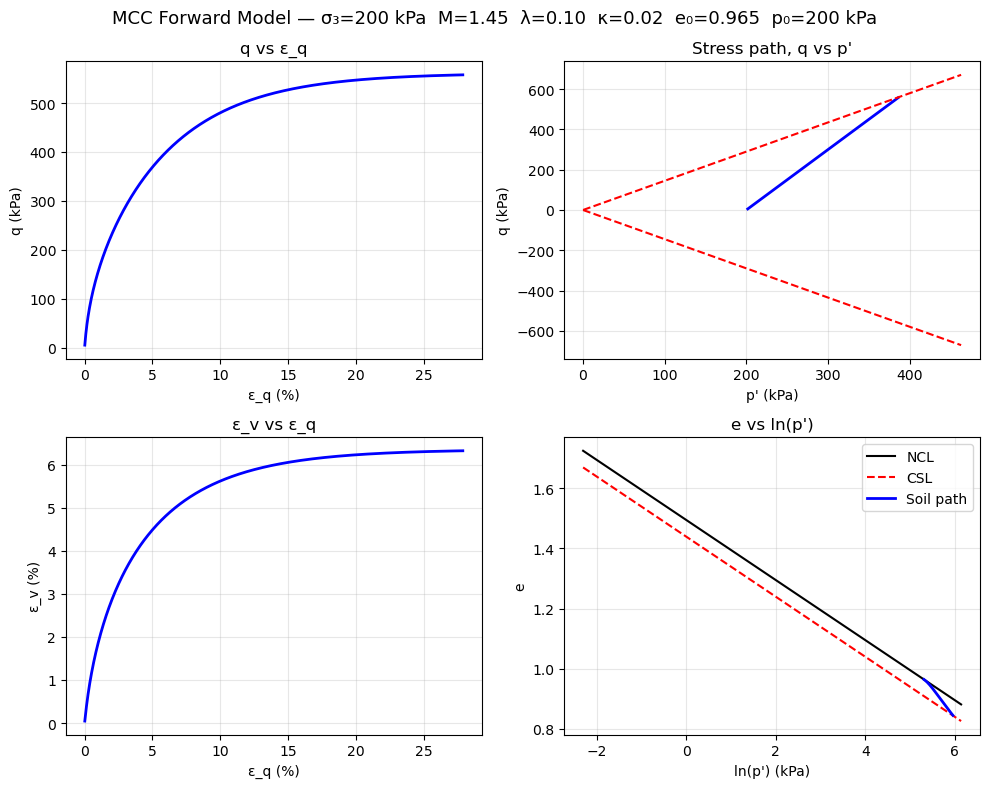

In [28]:
# forward model test run
Mval    = 1.45     
lam     = 0.10     # lambda (NCL slope)
kap     = 0.02    # kappa (recompression line)
nu      = 0.25    # Poisson's ratio
e0      = 0.965   # initial void ratio
p0_in   = 200      # initial YS size - NC: sigma3 = p0

params0 =  np.array([Mval, lam, kap, nu, e0, p0_in])

sigma3  = 200.0

q, eps_q, eps_v, p, e_out = MCC_forward(params0, sigma3, eps_max=0.3, n_steps=1000, load_tag=110, obs_eps1=None)    


# NCL and iso_NCL lines
p_range = np.linspace(0.1, p.max() * 1.2, 200)
Nval     = e0 - kap * np.log(p0_in / sigma3) + lam * np.log(p0_in)
gam = Nval - np.log(2) * (lam - kap) #intercept

e_ncl = Nval - lam * np.log(p_range)
e_csl = gam - lam * np.log(p_range)

q_csl = Mval * p_range

# figures
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# q vs eps_q
axes[0,0].plot(eps_q*100, q, 'b', lw=2)
axes[0,0].set_xlabel('ε_q (%)') 
axes[0,0].set_ylabel('q (kPa)')
axes[0,0].set_title('q vs ε_q') 
axes[0,0].grid(alpha=0.3)

# stress path
axes[0,1].plot(p, q, 'b', lw=2)
axes[0,1].plot(p_range, q_csl, 'r--', lw=1.5, label=f'CSL (M={Mval})')
axes[0,1].plot(p_range, -q_csl, 'r--', lw=1.5)
axes[0,1].set_xlabel("p' (kPa)")
axes[0,1].set_ylabel('q (kPa)')
axes[0,1].set_title("Stress path, q vs p'")
axes[0,1].grid(alpha=0.3)

# epsv vs eps_q
axes[1,0].plot(eps_q*100, eps_v*100, 'b', lw=2)
axes[1,0].set_xlabel('ε_q (%)')
axes[1,0].set_ylabel('ε_v (%)')
axes[1,0].set_title('ε_v vs ε_q')
axes[1,0].grid(alpha=0.3)

# e vs ln(p)
axes[1,1].plot(np.log(p_range), e_ncl,        'k-',  lw=1.5, label='NCL')
axes[1,1].plot(np.log(p_range), e_csl,        'r--', lw=1.5, label='CSL')
axes[1,1].plot(np.log(p),       e_out,        'b-',  lw=2,   label='Soil path')
axes[1,1].set_xlabel("ln(p') (kPa)")
axes[1,1].set_ylabel('e')
axes[1,1].set_title("e vs ln(p')")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle(f'MCC Forward Model — σ₃={sigma3:.0f} kPa  M={Mval:.2f}  λ={lam:.2f}  κ={kap:.2f}  e₀={e0:.3f}  p₀={p0_in:.0f} kPa', fontsize=13)
plt.tight_layout()
plt.show()

## Inversion

In [41]:
def objective_function_MCC(params, dobs, dpred, wphys, soiltype='sand'):
    q_obs    = dobs['q']
    epsv_obs = dobs['epsv']
    epsa_obs = dobs['epsa']
    e_obs    = dobs['e']
    q_pred    = dpred['q']
    epsv_pred = dpred['epsv']
    e_pred    = dpred['e']

    q_range    = np.ptp(dobs['q'])    if np.ptp(dobs['q'])    > 1e-10 else 1
    epsv_range = np.ptp(dobs['epsv']) if np.ptp(dobs['epsv']) > 1e-10 else 1
    e_range = np.ptp(e_obs) if np.ptp(e_obs) > 1e-10 else 1.

    ## Data Misfit
    phi_q       = np.sum(((q_pred - q_obs)/q_range)**2)
    phi_epsv    = np.sum(((epsv_pred - epsv_obs)/epsv_range)**2)
    phi_void    = np.sum(((e_pred - e_obs) / e_range)**2)
    phi_data    = phi_q + phi_epsv + phi_void

    Mval, lam, kap, nu, e0, p0_in = params

    Mval    = float(Mval)   # M = 6·sin(φ') / (3 - sin(φ')), silt 22º-30º: M=0.8-1.3; sand 30º-40º: M=1.3-1.6
    lam     = float(lam)    # compressibility - 0.05 - 0.2 sands, 0.2 - 0.5 silts
    kap     = float(kap)
    nu      = float(nu)
    e0      = float(e0)
    p0_in   = float(p0_in)  # no inversion for p0 - sticking to NC soils

    if soiltype == 'sand':                      
        M_min,      M_max   = 1.3,      1.6         
        lam_min,    lam_max = 0.01,     0.1
        kap_min,    kap_max = 0.001,    0.02
        nu_min,     nu_max  = 0.2,      0.3
        e0_min,     e0_max  = 0.4,      1.1
    elif soiltype == 'silt':
        M_min,      M_max   = 0.8,      1.3         
        lam_min,    lam_max = 0.1,      0.5
        kap_min,    kap_max = 0.03,     0.1
        nu_min,     nu_max  = 0.25,     0.35
        e0_min,     e0_max  = 0.5,      1.5
    
    ## Physics Misfit
    ## Scaled based on arbitrary offsets from bounds, M:0.1, lam:0.02, kap:0.05, nu:0.05, and e:0.05
    phi_phys    = ((max(0., M_min - Mval)/0.1)**2           # M lower bound
                 + (max(0., lam_min - lam)/0.02)**2     # lambda lower bound
                 + (max(0., kap_min - kap)/0.005)**2    # kappa lower bound
                 + (max(0., nu_min - nu)/0.05)**2            # poissons lower bound 
                 + (max(0., e0_min - e0)/0.1)**2            # void ratio lower bound
                 + (max(0., Mval - M_max)/0.1)**2           # M upper bound
                 + (max(0., lam - lam_max)/0.02)**2     # lambda upper bound
                 + (max(0., kap - kap_max)/0.005)**2    # kappa upper bound
                 + (max(0., nu - nu_max)/0.05)**2            # poissons upper bound 
                 + (max(0., e0 - e0_max)/0.1)**2            # void ratio upper bound
                 + (max(0., kap + 0.01 - lam )/0.01)**2)     # lambda > kappa + 0.01 (ensure gap)       

    phi = phi_data + wphys * phi_phys
    
    return phi, phi_q, phi_epsv, phi_void, phi_phys

In [6]:
# Phi Magnitude Check
data_dir = os.path.join('Karlsruhe-fine-sand-database-complete', 'TMD - triaxial-monotonic-drained')
test = 'TMD2'
dobs = loader_drained(test + '.dat', data_dir=data_dir)
sigma3 = dobs['sigma3']


params0  = np.array([1.7, 0.10, 0.02, 0.25, 0.965, sigma3])
q_pred, eps_q_pred, eps_v_pred, p_pred, e_pred = MCC_forward(params0, sigma3, eps_max=dobs['epsa'].max(), n_steps=1000, load_tag=110, obs_eps1=dobs['epsa'])  

dpred0   = {'q': q_pred, 'epsv': eps_v_pred, 'e': e_pred}

phi, phi_q, phi_epsv, phi_void, phi_phys = objective_function_MCC(params0, dobs, dpred0, wphys=2000, soiltype='sand')

print(f"phi_data  = {phi_q + phi_epsv + phi_void :.4f}")       # data misfit
print(f"phi_q     = {phi_q:.4f}")
print(f"phi_void  = {phi_void:.4f}")
print(f"phi_epsv  = {phi_epsv:.4f}")      
print(f"scaled phi_phys  = {phi - phi_q - phi_epsv - phi_void:.4f}")
print(f"phi_phys  = {phi_phys:.4f}")    # zero if within physical bounds
print(f"phi_total = {phi:.4f}")


phi_data  = 16859.4432
phi_q     = 65.9440
phi_void  = 8821.6046
phi_epsv  = 7971.8947
scaled phi_phys  = 2000.0000
phi_phys  = 1.0000
phi_total = 18859.4432


In [7]:
# w_phys check

param_names = ['M', 'lambda', 'kappa', 'nu', 'e0']

violations = [
    np.array([1.7,  0.10, 0.02,  0.25, 0.965, sigma3]),  # M too high by 0.1
    np.array([1.45, 0.12, 0.02,  0.25, 0.965, sigma3]),  # lam too high by 0.02
    np.array([1.45, 0.10, 0.025, 0.25, 0.965, sigma3]),  # kap too high by 0.005
    np.array([1.45, 0.10, 0.02,  0.32, 0.965, sigma3]),  # nu too high by 0.02
    np.array([1.45, 0.10, 0.02,  0.25, 0.35,  sigma3]),  # e0 too low by 0.05
]

for name, params_v in zip(param_names, violations):
    q_v, _, ev_v, _, e_v = MCC_forward(params_v, sigma3, eps_max=dobs['epsa'].max(), n_steps=1000, load_tag=110, obs_eps1=dobs['epsa'])
    dpred_v = {'q': q_v, 'epsv': ev_v, 'e': e_v}
    _, _, _, _, phi_phys_raw = objective_function_MCC(params_v, dobs, dpred_v, wphys=1, soiltype='sand')
    target_wphys = 0.1 * (phi_q + phi_epsv + phi_void) / (phi_phys_raw + 1e-10)
    print(f"{name:<10}: phi_phys={phi_phys_raw:.6f}  target wphys={target_wphys:.0f}")

M         : phi_phys=1.000000  target wphys=1686
lambda    : phi_phys=1.000000  target wphys=1686
kappa     : phi_phys=1.000000  target wphys=1686
nu        : phi_phys=0.160000  target wphys=10537
e0        : phi_phys=0.250000  target wphys=6744


## Newton's Method Inversion

In [10]:
def grad_hess_function_MCC(params, dobs, wphys=2000, soiltype = 'sand'):
# Taylor Series approx for 2nd derivative: [ f(x+h) - 2f(x) + f(x-h) ] / h^2
    
    grad = np.zeros(len(params))
    hess = np.zeros(len(params))
    sigma3 = dobs['sigma3']
    obs_eps1=dobs['epsa']

    # Mval, lam, kap, nu, e0, p0_in
    dx_abs = np.array([0.05, 0.005, 0.001, 0, 0.02, 0])  # scaled pertubation size for different parameters - p0/nu frozen
    q_now, _, eps_v_now, _, e_now  =   MCC_forward(params, sigma3,eps_max=obs_eps1.max(),n_steps=1000, load_tag=110, obs_eps1=obs_eps1)
    dpred_now = {'q': q_now, 'epsv': eps_v_now, 'e': e_now}
    phi_now, *_ = objective_function_MCC(params, dobs, dpred_now, wphys=wphys, soiltype=soiltype)
    

    for i in range(len(params)):

        dx = dx_abs[i] 
        params_up = params.copy()
        params_up[i] += dx
        params_down = params.copy()
        params_down[i] -= dx

        if dx == 0.:
            grad[i] = 0.
            hess[i] = 0.
            continue

        try:    
            q_up, _, eps_v_up, _, e_up = MCC_forward(params_up, sigma3, eps_max=obs_eps1.max(), n_steps=1000, load_tag=110, obs_eps1=obs_eps1)
            dpred_up = {'q': q_up, 'epsv': eps_v_up, 'e': e_up}
            phi_up, *_ = objective_function_MCC(params_up, dobs, dpred_up, wphys=wphys, soiltype=soiltype)

            q_down, _, eps_v_down, _, e_down = MCC_forward(params_down, sigma3, eps_max=obs_eps1.max(), n_steps=1000, load_tag=110, obs_eps1=obs_eps1)
            dpred_down = {'q': q_down, 'epsv': eps_v_down, 'e': e_down}
            phi_down, *_ = objective_function_MCC(params_down, dobs, dpred_down, wphys=wphys, soiltype=soiltype)
            
            grad[i] = (phi_up - phi_down) / (2 * dx)
            hess[i] = (phi_up - 2*phi_now + phi_down) / (dx**2)
        
        except Exception:
            hess[i] = 0.0
            grad[i] = 0.0
    
    return grad, hess

In [11]:
# gradient checks

paramsgrad = np.array([1.45, 0.10, 0.02, 0.25, 0.965, sigma3])

grad, hess = grad_hess_function_MCC(paramsgrad, dobs, wphys=1686, soiltype='sand')

param_names = ['M', 'λ', 'κ', 'ν', 'e0', 'p0']

print("Gradient:")
for i, name in enumerate(param_names):
    print(f"  dφ/d{name} = {grad[i]:.6f}")

print("\nHessian diagonal:")
for i, name in enumerate(param_names):
    print(f"  d²φ/d{name}² = {hess[i]:.6f}")

print("\nBig magnitudes since initial guess is far from the target")


Gradient:
  dφ/dM = 14582.422896
  dφ/dλ = 268476.411989
  dφ/dκ = -99701.783778
  dφ/dν = 0.000000
  dφ/de0 = -141077.111005
  dφ/dp0 = 0.000000

Hessian diagonal:
  d²φ/dM² = 14746.516733
  d²φ/dλ² = 5455198.068654
  d²φ/dκ² = 67892044.094644
  d²φ/dν² = 0.000000
  d²φ/de0² = 1491097.941175
  d²φ/dp0² = 0.000000

Big magnitudes since initial guess is far from the target


In [47]:
def newton_inversion_MCC(params_init, dobs, wphys=100, soiltype='sand', max_iter=100, tol_phi=1e-4, tol_hess=1e-4, verbose = False):

    params_now  = np.array(params_init, dtype=float)
    sigma3_obs  = dobs['sigma3']
    epsa_obs    = dobs['epsa']

    q_now, _, eps_v_now, _, e_now = MCC_forward(params_now, sigma3_obs, eps_max=epsa_obs.max(), n_steps=1000, load_tag=110, obs_eps1=epsa_obs)
    
    dpred_now = {'q': q_now, 'epsv': eps_v_now, 'e': e_now}
    phi_now, *_        = objective_function_MCC(params_now, dobs, dpred_now, wphys, soiltype)
    grad_now, hess_now = grad_hess_function_MCC(params_now, dobs, wphys, soiltype)

    phi_diff = 9999
    param_diff = 9999
    phi_history = [phi_now]
    i = 0

    while (phi_diff > tol_phi or param_diff > 1.0) and (i < max_iter):
        i += 1
        n_half = 0
        damping = 1.0 #reset at each iteration - damping used to halve the newton step

        step = np.array([-grad_now[j] / hess_now[j] if abs(hess_now[j]) > tol_hess else 0
                         for j in range(len(params_now))])
        
        max_step = np.array([0.2, 0.05, 0.01, 0.0, 0.1, 0.0])   # Mval, lam, kap, nu, e0, p0_in
        step = np.clip(step, -max_step, max_step)   # limits overstepping which was casuing issues with convergence

        while n_half < 100:
            params_update = params_now + damping * step
            params_update = np.clip(params_update, [1.0,  0.01, 0.001, 0.25, 0.4, sigma3_obs], [2.0,  0.5,  0.1,   0.25, 1.2, sigma3_obs])

            try: 
                q_update, _, eps_v_update, _, e_update = MCC_forward(params_update, sigma3_obs, eps_max=epsa_obs.max(), n_steps=1000, load_tag=110, obs_eps1=epsa_obs)
                dpred_update = {'q': q_update, 'epsv': eps_v_update, 'e': e_update}
                phi_update, *_ = objective_function_MCC(params_update, dobs, dpred_update, wphys, soiltype)
            except Exception:
                damping *= 0.5
                n_half += 1
                continue      

            if phi_update < phi_now:
                phi_diff   = abs(phi_update - phi_now)
                param_diff = np.max(np.abs(params_update - params_now) / np.array([0.1, 0.01, 0.005, 0.25, 0.05, 1.]))
                params_now = params_update
                phi_now    = phi_update
                grad_now, hess_now = grad_hess_function_MCC(params_now, dobs, wphys, soiltype)
                phi_history.append(phi_update)
                break
            damping *= 0.5
            n_half += 1

        if n_half == 100:
            print(f"Line search failed at iteration {i} — stopping")
            break

    q_final, _, eps_v_final, p_final, e_final = MCC_forward(params_now, sigma3_obs, eps_max=epsa_obs.max(), n_steps=1000, load_tag=110, obs_eps1=epsa_obs)
    dpred_final = {'q': q_final, 'epsv': eps_v_final, 'p': p_final, 'e': e_final}
    phi_final, phi_q, phi_epsv, phi_void, phi_phys = objective_function_MCC(params_now, dobs, dpred_final, wphys, soiltype)

    Mval_out, lam_out, kap_out, nu_out, e0_out, p0_out = params_now
    
    if verbose:
        print(f"Converged in {i} iterations")
        print(f"M  = {Mval_out:.3f}")
        print(f"λ  = {lam_out:.4f}")
        print(f"κ  = {kap_out:.4f}")
        print(f"e0 = {e0_out:.3f}")
        print(f"phi_total = {phi_final:.4f}")

    return params_now, phi_history, dpred_final

In [42]:
## Single Inversion Run

data_dir = os.path.join('Karlsruhe-fine-sand-database-complete', 'TMD - triaxial-monotonic-drained')
test = 'TMD2'
dobs = loader_drained(test + '.dat', data_dir=data_dir)
# returns epsa, epsv, epsq, p, q , sigma3, time

sigma3 = dobs['sigma3']
nu = 0.25

params_init = np.array([1.4, 0.08, 0.01, nu, 0.824, sigma3])

tol=1e-7
params_out, phi_history, dpred_final = newton_inversion_MCC(params_init, dobs, wphys=2000, soiltype='sand', max_iter=100, tol_phi=tol, tol_hess=tol)

Converged in 5 iterations
M  = 1.323
λ  = 0.0306
κ  = 0.0199
e0 = 0.979
phi_total = 86.6949


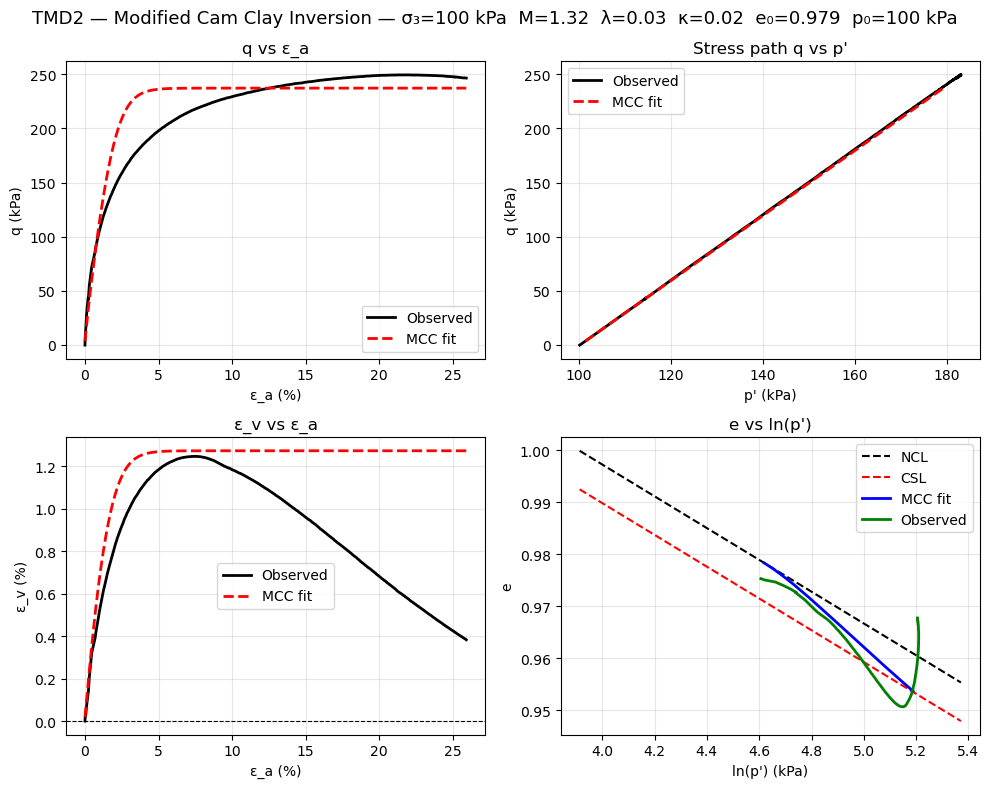

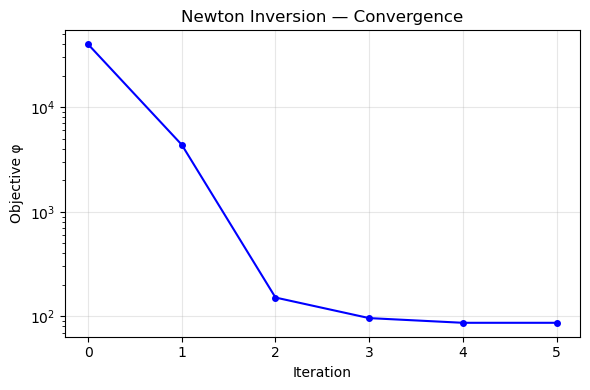

In [44]:
Mval_out, lam_out, kap_out, nu_out, e0_out, p0_out = params_out

# NCL and iso_NCL lines
p_range = np.linspace(sigma3 * 0.5, dpred_final['p'].max() * 1.2, 200)
Nval_out    = e0_out - kap_out * np.log(p0_out / sigma3) + lam_out * np.log(p0_out)
gam_out     = Nval_out - np.log(2) * (lam_out - kap_out)
e_out       = dpred_final['e']
p           = dpred_final['p']

e_ncl_out = Nval_out - lam_out * np.log(p_range)
e_csl_out = gam_out - lam_out * np.log(p_range)

q_csl_out = Mval_out * p_range

## Plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# q vs eps_a
axes[0,0].plot(dobs['epsa']*100,        dobs['q'],          'k-',  lw=2, label='Observed')
axes[0,0].plot(dobs['epsa']*100,        dpred_final['q'],   'r--', lw=2, label='MCC fit')
axes[0,0].set_xlabel('ε_a (%)')
axes[0,0].set_ylabel('q (kPa)')
axes[0,0].set_title('q vs ε_a')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# q vs p
axes[0,1].plot(dobs['p'],               dobs['q'],          'k-',  lw=2, label='Observed')
axes[0,1].plot(dpred_final['p'],        dpred_final['q'],   'r--', lw=2, label='MCC fit')
axes[0,1].set_xlabel("p' (kPa)")
axes[0,1].set_ylabel('q (kPa)')
axes[0,1].set_title("Stress path q vs p'")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# epsv vs eps_a
axes[1,0].plot(dobs['epsa']*100,        dobs['epsv']*100,         'k-',  lw=2, label='Observed')
axes[1,0].plot(dobs['epsa']*100,        dpred_final['epsv']*100,  'r--', lw=2, label='MCC fit')
axes[1,0].set_xlabel('ε_a (%)')
axes[1,0].set_ylabel('ε_v (%)')
axes[1,0].set_title('ε_v vs ε_a')
axes[1,0].axhline(0, color='k', lw=0.8, ls='--')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# e vs ln(p)
axes[1,1].plot(np.log(p_range),        e_ncl_out,        'k--',  lw=1.5, label='NCL')
axes[1,1].plot(np.log(p_range),        e_csl_out,        'r--', lw=1.5, label='CSL')
axes[1,1].plot(np.log(dpred_final['p']), dpred_final['e'], 'b-',  lw=2,   label='MCC fit')
axes[1,1].plot(np.log(dobs['p']),      dobs['e'],        'g-',  lw=2,   label='Observed')
axes[1,1].set_xlabel("ln(p') (kPa)")
axes[1,1].set_ylabel('e')
axes[1,1].set_title("e vs ln(p')")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle(f'{test} — Modified Cam Clay Inversion — σ₃={sigma3:.0f} kPa  M={Mval_out:.2f}  λ={lam_out:.2f}  κ={kap_out:.2f}  e₀={e0_out:.3f}  p₀={p0_out:.0f} kPa', fontsize=13)
plt.tight_layout()
plt.show()

# convergence plot
plt.figure(figsize=(6, 4))
plt.plot(phi_history, 'b-o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Objective φ')
plt.title('Newton Inversion — Convergence')
plt.yscale('log')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
## Plots (for loop)

def plot_MCC_inversion(test, dobs, dpred_final, params_out, output_dir):
    
    Mval_out, lam_out, kap_out, nu_out, e0_out, p0_out = params_out
    sigma3 = dobs['sigma3']

    # NCL and iso_NCL lines
    p_range = np.linspace(sigma3 * 0.5, dpred_final['p'].max() * 1.2, 200)
    Nval_out    = e0_out - kap_out * np.log(p0_out / sigma3) + lam_out * np.log(p0_out)
    gam_out     = Nval_out - np.log(2) * (lam_out - kap_out)
    e_out       = dpred_final['e']
    p           = dpred_final['p']

    e_ncl_out = Nval_out - lam_out * np.log(p_range)
    e_csl_out = gam_out - lam_out * np.log(p_range)

    q_csl_out = Mval_out * p_range

    ## Plots
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # q vs eps_a
    axes[0,0].plot(dobs['epsa']*100,        dobs['q'],          'k-',  lw=2, label='Observed')
    axes[0,0].plot(dobs['epsa']*100,        dpred_final['q'],   'r--', lw=2, label='MCC fit')
    axes[0,0].set_xlabel('ε_a (%)')
    axes[0,0].set_ylabel('q (kPa)')
    axes[0,0].set_title('q vs ε_a')
    axes[0,0].legend()
    axes[0,0].grid(alpha=0.3)

    # q vs p
    axes[0,1].plot(dobs['p'],               dobs['q'],          'k-',  lw=2, label='Observed')
    axes[0,1].plot(dpred_final['p'],        dpred_final['q'],   'r--', lw=2, label='MCC fit')
    axes[0,1].set_xlabel("p' (kPa)")
    axes[0,1].set_ylabel('q (kPa)')
    axes[0,1].set_title("Stress path q vs p'")
    axes[0,1].legend()
    axes[0,1].grid(alpha=0.3)

    # epsv vs eps_a
    axes[1,0].plot(dobs['epsa']*100,        dobs['epsv']*100,         'k-',  lw=2, label='Observed')
    axes[1,0].plot(dobs['epsa']*100,        dpred_final['epsv']*100,  'r--', lw=2, label='MCC fit')
    axes[1,0].set_xlabel('ε_a (%)')
    axes[1,0].set_ylabel('ε_v (%)')
    axes[1,0].set_title('ε_v vs ε_a')
    axes[1,0].axhline(0, color='k', lw=0.8, ls='--')
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)

    # e vs ln(p)
    axes[1,1].plot(np.log(p_range),        e_ncl_out,        'k--',  lw=1.5, label='NCL')
    axes[1,1].plot(np.log(p_range),        e_csl_out,        'r--', lw=1.5, label='CSL')
    axes[1,1].plot(np.log(dpred_final['p']), dpred_final['e'], 'b-',  lw=2,   label='MCC fit')
    axes[1,1].plot(np.log(dobs['p']),      dobs['e'],        'g-',  lw=2,   label='Observed')
    axes[1,1].set_xlabel("ln(p') (kPa)")
    axes[1,1].set_ylabel('e')
    axes[1,1].set_title("e vs ln(p')")
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)

    plt.suptitle(f'{test} — Modified Cam Clay Inversion — σ₃={sigma3:.0f} kPa  M={Mval_out:.2f}  λ={lam_out:.2f}  κ={kap_out:.2f}  e₀={e0_out:.3f}  p₀={p0_out:.0f} kPa', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{test}_MCCplots.png'), dpi=150, bbox_inches='tight')
    plt.close()

In [50]:
results = []
output_dir = 'outputs_MCC'
os.makedirs(output_dir, exist_ok=True)

for n in range(1, 26):
    data_dir = os.path.join('Karlsruhe-fine-sand-database-complete', 'TMD - triaxial-monotonic-drained')
    test = f'TMD{n}'
    filepath = os.path.join(data_dir, test + '.dat')

    if not os.path.exists(filepath):
        print(f"{test}: file not found — skipping")
        continue
    
    try:
        dobs = loader_drained(test + '.dat', data_dir=data_dir)
        
        nu = 0.25
        tol=1e-5
        sigma3 = dobs['sigma3']
        params_init = np.array([1.4, 0.08, 0.01, nu, dobs['e'][0], sigma3])
        params_out, phi_history, dpred_final = newton_inversion_MCC(params_init, dobs, wphys=2000, soiltype='sand', max_iter=100, tol_phi=tol, tol_hess=tol, verbose=False)
        Mval_out, lam_out, kap_out, nu_out, e0_out, p0_out = params_out
        n_iter = len(phi_history) - 1
        results.append([test, round(dobs['sigma3']), Mval_out, lam_out, kap_out, e0_out, n_iter])
        plot_MCC_inversion(test, dobs, dpred_final, params_out, output_dir)
        plot_convergence(test, phi_history, output_dir)

    except Exception as e:
        print(f"{test}: failed — {e}")

print(f"{'Test':<8} {'σ3':>8} {'M':>6} {'λ':>7} {'κ':>7} {'e0':>7} {'iters':>6}")
print("-" * 55)
for r in results:
    print(f"{r[0]:<8} {r[1]:>8} {r[2]:>6.3f} {r[3]:>7.4f} {r[4]:>7.4f} {r[5]:>7.3f} {r[6]:>6}")

Line search failed at iteration 4 — stopping
Line search failed at iteration 3 — stopping
Line search failed at iteration 3 — stopping
Line search failed at iteration 3 — stopping


/Users/lambert/Documents/UBC/Final Paper/UBC EOSC Capstone Project/project_utils.py:490: RuntimeWarning: divide by zero encountered in scalar divide
  K     = (1. + e) * p_now / kap #stress dependent stiffness - 19.3 Puzrin
/Users/lambert/Documents/UBC/Final Paper/UBC EOSC Capstone Project/project_utils.py:46: RuntimeWarning: invalid value encountered in scalar subtract
  t2 = K - 2./3.*G


Line search failed at iteration 4 — stopping
Line search failed at iteration 4 — stopping
Line search failed at iteration 4 — stopping
Line search failed at iteration 4 — stopping
Line search failed at iteration 4 — stopping
Test           σ3      M       λ       κ      e0  iters
-------------------------------------------------------
TMD1           51  1.317  0.0314  0.0200   1.003      5
TMD2          100  1.317  0.0312  0.0200   0.983      5
TMD3          201  1.339  0.0369  0.0195   0.978     11
TMD4          300  1.309  0.0363  0.0194   0.972     12
TMD5          398  1.324  0.0415  0.0193   0.961     14
TMD6           50  1.337  0.0321  0.0195   0.925      3
TMD7          101  1.312  0.0300  0.0200   0.933      3
TMD8          199  1.324  0.0310  0.0198   0.915      4
TMD9          298  1.324  0.0310  0.0198   0.905      4
TMD10         401  1.355  0.0305  0.0193   0.879      5
TMD11          51  1.312  0.0300  0.0200   0.927      2
TMD12         101  1.312  0.0300  0.0200   0.90

In [11]:
df = pd.DataFrame(results, columns=['Test', 'σ3 (kPa)', 'K (MPa)', 'G (MPa)', 'φ (°)', 'ψ (°)', 'iters'])
df.to_excel(os.path.join(output_dir, 'MC_inversion_results.xlsx'), index=False)
print(f"\nResults saved to {os.path.join(output_dir, 'MC_inversion_results.xlsx')}")


Results saved to outputs/MC_inversion_results.xlsx
